## Introduction

### 1. Five real-life applications of Machine Learning
1. House price prediction: predicting the price of a house based on its features (size, location, number of rooms).
2. Medical diagnosis: predicting whether a patient has a disease based on symptoms and medical tests.
3. Spam detection: classifying emails as spam or not spam.
4. Recommendation systems: suggesting products or movies based on user behavior.
5. Credit scoring: predicting whether a customer will repay a loan.

### 2. Classification of tasks (Supervised / Unsupervised)
Supervised Learning:
Tasks where we have input data X and known output labels y, such as house price prediction or disease classification.

Unsupervised Learning:
Tasks where we only have input data X without labels, such as clustering customers into groups based on their behavior.

### 3. Multiclass vs Multilabel
Multiclass classification:
Each sample belongs to exactly one class (e.g. an image is either a cat, a dog, or a bird).

Multilabel classification:
Each sample can belong to multiple classes at the same time (e.g. a movie can be both action and comedy).

### 4. Is house price prediction a classification or regression problem?
House price prediction is a regression problem because the target variable (price) is a continuous numerical value.

It can be converted to a classification problem by dividing prices into categories (e.g. low, medium, high), but the original task is regression.

In [6]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import PolynomialFeatures  
from sklearn.linear_model import LinearRegression  
from sklearn.tree import DecisionTreeRegressor  
from sklearn.metrics import mean_absolute_error, mean_squared_error  

In [ ]:
# Load the dataset
data = pd.read_json("data/train.json")

In [85]:
# check_data (Get number of rows and columns)
rows, columns = data.shape

print("Number of rows:", rows)
print("Number of columns:", columns)
print(data.columns)
data.isnull().sum()

Number of rows: 49352
Number of columns: 15
Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')


bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

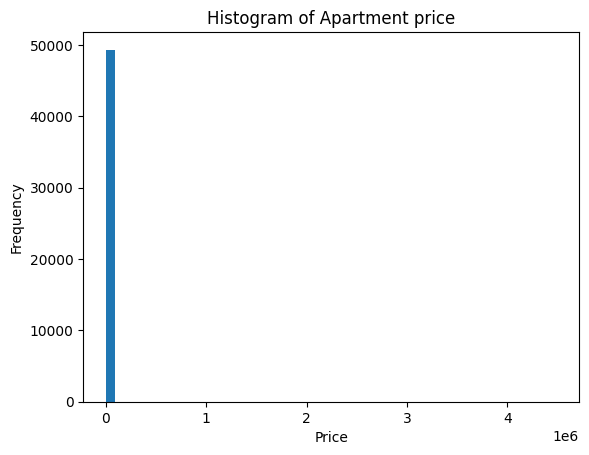

In [86]:
#Histogram of Apartment price(to know how to handed)
plt.hist(data['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Apartment price')
plt.show()

In [91]:
cols = ['price', 'bathrooms', 'bedrooms', 'interest_level']
df = data[cols].copy()
df.head()
df.info()
df.describe() #give some statictics 

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price           49352 non-null  int64  
 1   bathrooms       49352 non-null  float64
 2   bedrooms        49352 non-null  int64  
 3   interest_level  49352 non-null  object 
dtypes: float64(1), int64(2), object(1)
memory usage: 1.9+ MB


,price,bathrooms,bedrooms
count,4.935200e+04,49352.00000,49352.000000
mean,3.830174e+03,1.21218,1.541640
std,2.206687e+04,0.50142,1.115018
min,4.300000e+01,0.00000,0.000000
25%,2.500000e+03,1.00000,1.000000
50%,3.150000e+03,1.00000,1.000000
75%,4.100000e+03,1.00000,2.000000
max,4.490000e+06,10.00000,8.000000


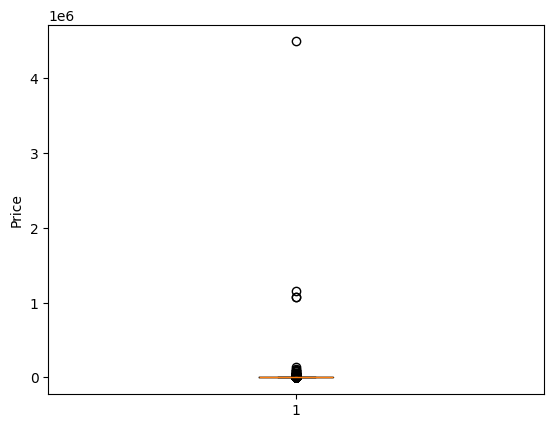

In [92]:
#boxplot of apartment prices to visualize the distribution and detect outliers
plt.boxplot(df['price'])
plt.ylabel('Price')
plt.show()

In [98]:
# Compute the 1st and 99th percentiles of price to identify extreme outliers
low = df['price'].quantile(0.01)
high = df['price'].quantile(0.99)

print(f"Low = {low}: the price below which the cheapest 1% of apartments fall.")
print(f"High = {high}: the price above which the most expensive 1% of apartments fall.")

Low = 1475.0: the price below which the cheapest 1% of apartments fall.
High = 13000.0: the price above which the most expensive 1% of apartments fall.


In [99]:
# Remove outliers by keeping only apartments with prices between the 1st and 99th percentiles
df_clean = df[(df['price'] >= low) & (df['price'] <= high)]
df_clean.shape

(48379, 4)

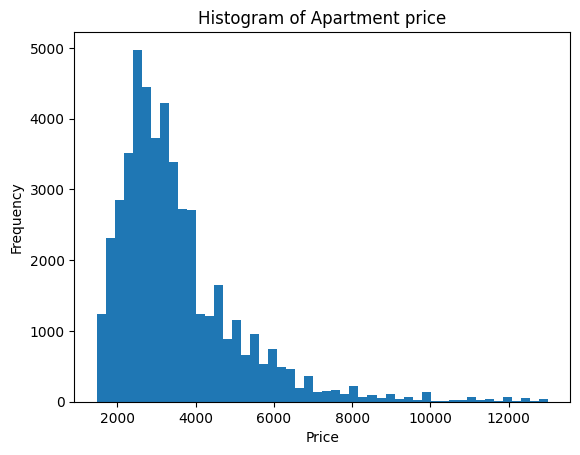

In [101]:
# Plot the histogram of apartment prices after removing outliers
# This shows the distribution of prices in the cleaned dataset
plt.hist(df_clean['price'], bins=50)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Apartment price')
plt.show()

In [103]:
# Count how many apartments fall into each interest level (low, medium, high)
df_clean['interest_level'].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [107]:
# Encode the categorical column 'interest_level' into numeric values
# low -> 0, medium -> 1, high -> 2
mapping = {'low': 0, 'medium': 1, 'high': 2}
df_clean['interest_level_encoded'] = df_clean['interest_level'].map(mapping)
df_clean[['interest_level', 'interest_level_encoded']].head()

/var/folders/32/gyhr77kj37xfbcdxcp3tztfh0000gn/T/ipykernel_36499/2809841968.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['interest_level_encoded'] = df_clean['interest_level'].map(mapping)


,interest_level,interest_level_encoded
4,medium,1
6,low,0
9,medium,1
10,medium,1
15,low,0


In [110]:
# Compute the correlation matrix between price, bathrooms, bedrooms and encoded interest level
# This helps us understand how strongly each feature is related to the target (price)
corr = df_clean[['price', 'bathrooms', 'bedrooms', 'interest_level_encoded']].corr()
corr

,price,bathrooms,bedrooms,interest_level_encoded
price,1.000000,0.671943,0.545948,-0.200111
bathrooms,0.671943,1.000000,0.517574,-0.063635
bedrooms,0.545948,0.517574,1.000000,0.050654
interest_level_encoded,-0.200111,-0.063635,0.050654,1.000000


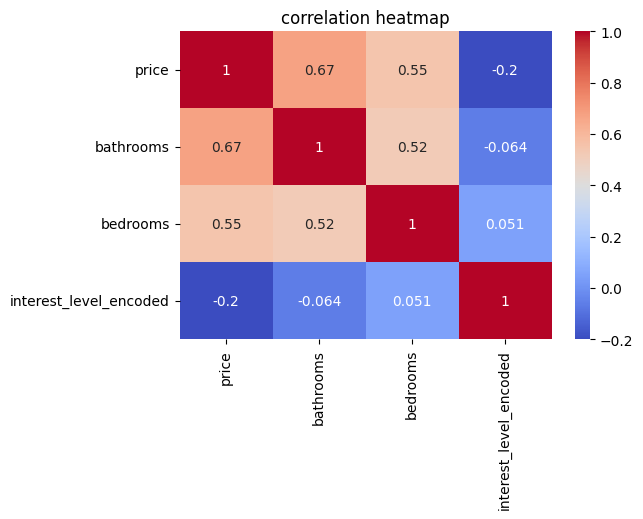

In [111]:
# Plot a heatmap to visualize the correlation matrix
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('correlation heatmap')
plt.show()

## correlation
##  There is a positive correlation between price and number of bathrooms. 
##  There is a positive but weaker correlation between price and number of bedrooms.
##  There is a weak negative correlation between price and interest level.

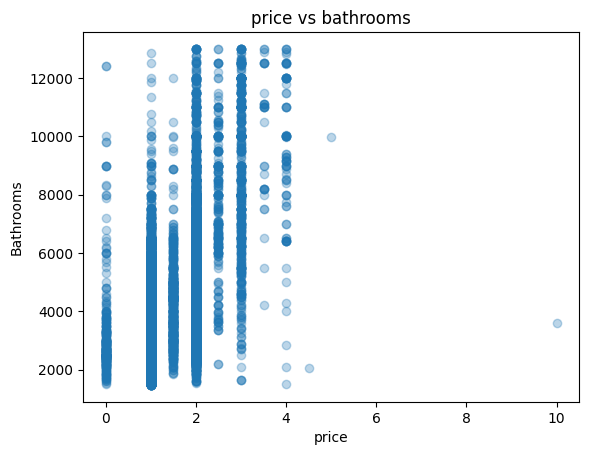

In [112]:
# Scatter plot to visualize the relationship between number of bathrooms and apartment price
plt.scatter(df_clean['bathrooms'], df_clean['price'], alpha=0.3)
plt.ylabel('Bathrooms')
plt.xlabel('price')
plt.title('price vs bathrooms')
plt.show()

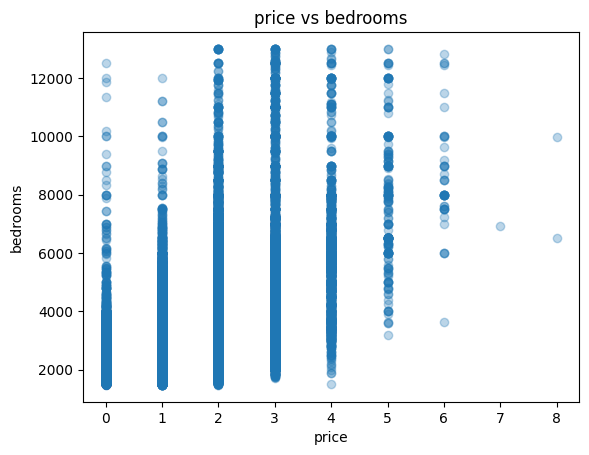

In [113]:
# same for bedrooms..
plt.scatter(df_clean['bedrooms'], df_clean['price'], alpha=0.3)
plt.ylabel('bedrooms')
plt.xlabel('price')
plt.title('price vs bedrooms')
plt.show()

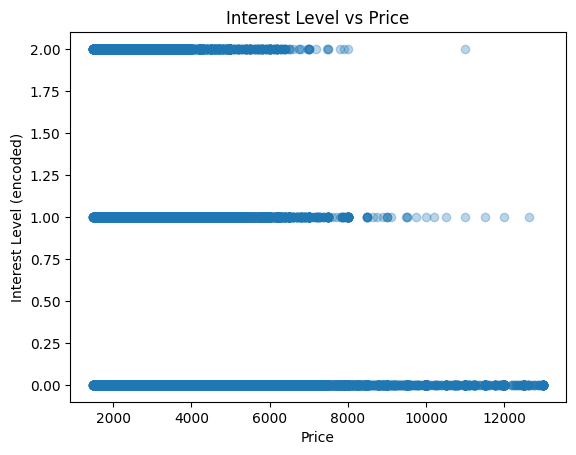

In [116]:
# for interestLevel
plt.scatter(df_clean['price'], df_clean['interest_level_encoded'], alpha=0.3)
plt.xlabel('Price')
plt.ylabel('Interest Level (encoded)')
plt.title('Interest Level vs Price')
plt.show()

In [117]:
# Define input features (bathrooms, bedrooms) and target variable (price)
x = df_clean[['bathrooms', 'bedrooms']]
y = df_clean['price']
x.shape, y.shape 

((48379, 2), (48379,))

In [119]:
# 80% for training and 20% for testing, with a fixed random state for reproducibility
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((38703, 2), (9676, 2), (38703,), (9676,))

In [120]:
#transform to polynomialFeatures
poly = PolynomialFeatures(degree=10, include_bias=False)

x_train_poly = poly.fit_transform(x_train)
x_train_poly.shape

x_test_poly = poly.transform(x_test)
x_test_poly.shape

(9676, 65)

## why we need to use poly for leanir:
### (cuz its it's a leaner model we need to improve complexty in order to understand non-leanir relationship)

In [121]:
#Train linear regression model
lin_model = LinearRegression()
lin_model.fit(x_train_poly, y_train)

LinearRegression()

In [122]:
#testing 
lin_model.score(x_test_poly, y_test)
print(lin_model.score(x_test_poly, y_test))

0.5221292593779703


### The R² score on the test set is about 0.52, which means that the model explains approximately 52% of the variance in apartment prices using the features (bathrooms and bedrooms).

In [124]:
# Generate predictions for training and test sets using the trained linear regression model
y_train_pred = lin_model.predict(x_train_poly)  # predictions on training data
y_test_pred = lin_model.predict(x_test_poly)    # predictions on test data
y_test_pred[:10]

array([3199.30407215, 2477.6576367 , 3199.30407215, 3036.23907416,
       2477.6576367 , 2477.6576367 , 2477.6576367 , 3872.81145379,
       3199.30407215, 3036.23907416])

In [125]:
# count MAE&RMSE for linear regression
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_train, mae_test, rmse_train, rmse_test

(755.3454907329793,
 760.7357919219053,
 np.float64(1075.2521568915959),
 np.float64(1100.0286487534827))

## MAE (Mean Absolute Error)

MAE means: the average size of the prediction error.

For each apartment:
Error = Real Price − Predicted Price  
We take the absolute value so the error is always positive.

Then we compute:

MAE = (Sum of |Real Price − Predicted Price| for all apartments) ÷ Number of apartments

In simple words:  
MAE tells us: *On average, how many dollars is the model wrong by?*  
All errors are treated equally.


## RMSE (Root Mean Squared Error)

RMSE is similar to MAE, but it gives more importance to large mistakes.

Steps:

1. Error = Real Price − Predicted Price  
2. Square the error: (Real − Predicted)²  
3. Take the average of all squared errors (this is MSE)  
4. Take the square root to return to the price unit

So:

RMSE = sqrt( (Sum of (Real Price − Predicted Price)²) ÷ Number of apartments )

In simple words:  
RMSE tells us the typical error size, but it strongly penalizes very large errors.
If the model makes a few big mistakes, RMSE becomes much larger than MAE.

## linear Regression --> Smooth equation
## decision tree --> complex equation use likke(if-then), for thats why why not use polymaianFeature befor train

In [126]:
#trainDecisionTreeRegressor
tree_model = DecisionTreeRegressor(random_state=21)
tree_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
y_train_pred_tree = tree_model.predict(x_train)
y_test_pred_tree = tree_model.predict(x_test)

print(y_train_pred_tree, y_test_pred_tree)

[2477.57604138 3873.00312609 3199.50211598 ... 2477.57604138 3036.10009935
 2477.57604138] [3199.50211598 2477.57604138 3199.50211598 ... 3199.50211598 3873.00312609
 3199.50211598]


In [127]:
mae_train_tree = mean_absolute_error(y_train, y_train_pred_tree)
mae_test_tree = mean_absolute_error(y_test, y_test_pred_tree)

rmse_train_tree = np.sqrt(mean_squared_error(y_train, y_train_pred_tree))
rmse_test_tree = np.sqrt(mean_squared_error(y_test, y_test_pred_tree))

mae_train_tree, mae_test_tree, rmse_train_tree, rmse_test_tree

(755.3526969807441,
 759.5264138392399,
 np.float64(1075.2064336888793),
 np.float64(1089.2319132106552))

In [128]:
# Naive baseline model (Mean):
# Idea: predict the SAME value for every apartment (the mean price from the training set).
# This is a "dumb" baseline. If our ML models can't beat it, they're not useful.
mean_price = y_train.mean()
y_train_pred_mean = np.full_like(y_train, mean_price)
y_test_pred_mean = np.full_like(y_test, mean_price)

mae_train_mean = mean_absolute_error(y_train, y_train_pred_mean)
mae_test_mean  = mean_absolute_error(y_test, y_test_pred_mean)
rmse_train_mean = np.sqrt(mean_squared_error(y_train, y_train_pred_mean))
rmse_test_mean  = np.sqrt(mean_squared_error(y_test, y_test_pred_mean))

mae_train_mean, mae_test_mean, rmse_train_mean, rmse_test_mean

(1137.6911092163398,
 1143.0090946672178,
 np.float64(1599.2294726066657),
 np.float64(1591.3040162382256))

In [129]:
# Naive baseline model (Median):
# Idea: predict the SAME value for every apartment (the median price from the training set).
# Compute the median price from TRAINING targets only
median_price = np.median(y_train)

# Create predictions for TRAIN data (all values = median_price)
y_train_pred_median = np.full_like(y_train, median_price)

# Create predictions for TEST data (all values = median_price)
y_test_pred_median = np.full_like(y_test, median_price)

mae_train_median = mean_absolute_error(y_train, y_train_pred_median)
mae_test_median  = mean_absolute_error(y_test, y_test_pred_median)
rmse_train_median = np.sqrt(mean_squared_error(y_train, y_train_pred_median))
rmse_test_median  = np.sqrt(mean_squared_error(y_test, y_test_pred_median))

mae_train_median, mae_test_median, rmse_train_median, rmse_test_median


(1084.5892566467717,
 1092.6953286482017,
 np.float64(1645.4495405596206),
 np.float64(1639.3751798039061))

In [130]:
#Comparison tables:

result_MAE = pd.DataFrame({
    'model': ['linear_regression', 'decision_tree', 'naive_mean', 'naive_median'],
    'train': [mae_train, mae_train_tree, mae_train_mean, mae_train_median],
    'test':  [mae_test,  mae_test_tree,  mae_test_mean,  mae_test_median]
})

result_MAE


result_RMSE = pd.DataFrame({
    'model': ['linear_regression', 'decision_tree', 'naive_mean', 'naive_median'],
    'train': [rmse_train, rmse_train_tree, rmse_train_mean, rmse_train_median],
    'test':  [rmse_test,  rmse_test_tree,  rmse_test_mean,  rmse_test_median]
})

result_RMSE

,model,train,test
0,linear_regression,1075.252157,1100.028649
1,decision_tree,1075.206434,1089.231913
2,naive_mean,1599.229473,1591.304016
3,naive_median,1645.449541,1639.375180


### From the MAE results, the Decision Tree model achieves the lowest error on both the training and test sets, which means it provides the most accurate price predictions among all tested models.

### Both naive baselines (mean and median) have much higher errors, showing that using only a constant value is not sufficient and that the machine learning models are able to learn useful patterns from the features (bathrooms and bedrooms).